# Chromatin Accessibility Predictor

Using JAX to predict ATAC-seq open chromatin regions from raw DNA sequence.

Dataset: ENCODE REST API, hg38 chr22

In [1]:
!pip install -q "jax[cuda12]" flax optax requests pyfaidx scikit-learn matplotlib seaborn logomaker tqdm pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 82.6 MB/s eta 0:00:00


In [2]:
import os, gzip, shutil, requests
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logomaker
from tqdm import tqdm

import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
from flax.training import train_state
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)

In [3]:
DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)
PLOT_DIR = Path("plots"); PLOT_DIR.mkdir(exist_ok=True)
GENOME_FA = DATA_DIR / "hg38_chr22.fa"

In [22]:
SEQ_LEN=2048
BATCH_SIZE = 64
EPOCHS     = 100
LR         = 3e-4
N_FILTERS  = 128
N_LAYERS   = 5
SEED       = 42
rng        = np.random.default_rng(SEED)

print("JAX version:", jax.__version__)
print("Devices:", jax.devices())

JAX version: 0.7.2
Devices: [CudaDevice(id=0)]


In [23]:
def download_file(url: str, dest: Path, desc: str = "") -> Path:
    if dest.exists():
        print(f"[skip] {dest.name} already present.")
        return dest
    print(f"[download] {desc or dest.name} ...")
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(dest, "wb") as f:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk)
    print(f"  saved {dest}")
    return dest


In [24]:
ENCODE_BASE = "https://www.encodeproject.org"
CELL_LINE   = "K562"

print(f"[ENCODE] Querying ATAC-seq experiments for {CELL_LINE} ...")
search_params = {
    "type": "Experiment",
    "assay_title": "ATAC-seq",
    "biosample_ontology.term_name": CELL_LINE,
    "status": "released",
    "replicates.library.biosample.donor.organism.scientific_name": "Homo sapiens",
    "format": "json",
    "limit": 5,
}
resp = requests.get(f"{ENCODE_BASE}/search/",
                    params=search_params,
                    headers={"Accept": "application/json"},
                    timeout=30)
resp.raise_for_status()
experiments = resp.json().get("@graph", [])
assert experiments, "No experiments returned — check ENCODE API."

exp_accession = experiments[0]["accession"]
print(f"  Using experiment: {exp_accession}")

# fetch file list for this experiment
exp_resp = requests.get(f"{ENCODE_BASE}/experiments/{exp_accession}/",
                        headers={"Accept": "application/json"}, timeout=30)
exp_resp.raise_for_status()
files = exp_resp.json().get("files", [])

peak_url = None
for f in files:
    if (f.get("file_format") == "bed"
            and f.get("output_type") == "IDR thresholded peaks"
            and f.get("status") == "released"):
        href = f.get("href") or f.get("cloud_metadata", {}).get("url", "")
        if href:
            peak_url = href if href.startswith("http") else ENCODE_BASE + href
            break

assert peak_url, "No IDR-thresholded narrowPeak found — try a different experiment."
print(f"  Peak file URL: {peak_url}")

PEAK_FILE = DATA_DIR / "K562_atac_peaks.bed.gz"
download_file(peak_url, PEAK_FILE, "ATAC-seq narrowPeak")


[ENCODE] Querying ATAC-seq experiments for K562 ...
  Using experiment: ENCSR956DNB
  Peak file URL: https://www.encodeproject.org/files/ENCFF738NOA/@@download/ENCFF738NOA.bed.gz
[skip] K562_atac_peaks.bed.gz already present.


PosixPath('data/K562_atac_peaks.bed.gz')

In [25]:
if not GENOME_FA.exists():
    gz = DATA_DIR / "chr22.fa.gz"
    download_file(
        "https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr22.fa.gz",
        gz, "hg38 chr22 FASTA"
    )
    print("[decompress] chr22.fa.gz ...")
    with gzip.open(gz, "rb") as fin, open(GENOME_FA, "wb") as fout:
        shutil.copyfileobj(fin, fout)
    gz.unlink()
    print(f"  → saved {GENOME_FA}")
else:
    print(f"[skip] {GENOME_FA.name} already present.")

[skip] hg38_chr22.fa already present.


In [26]:
from pyfaidx import Fasta

In [27]:
BASE2IDX = {"A": 0, "C": 1, "G": 2, "T": 3,
            "a": 0, "c": 1, "g": 2, "t": 3}

def one_hot(seq: str) -> np.ndarray:
    ohe = np.zeros((4, len(seq)), dtype=np.float32)
    for i, b in enumerate(seq):
        idx = BASE2IDX.get(b)
        if idx is not None:
            ohe[idx, i] = 1.0
    return ohe

In [28]:
print("[genome] Loading chr22 ...")
genome    = Fasta(str(GENOME_FA))
CHROM_SEQ = str(genome["chr22"])
CHROM_LEN = len(CHROM_SEQ)
print(f"  chr22 length: {CHROM_LEN:,} bp")

[genome] Loading chr22 ...
  chr22 length: 50,818,468 bp


In [29]:
def parse_narrowpeak(path: Path, chrom: str = "chr22") -> List[Tuple[int,int,float]]:
    opener = gzip.open if str(path).endswith(".gz") else open
    peaks = []
    with opener(path, "rt") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            cols = line.strip().split("\t")
            if cols[0] != chrom:
                continue
            signal = float(cols[6]) if len(cols) > 6 else 1.0
            peaks.append((int(cols[1]), int(cols[2]), signal))
    return peaks

peaks = parse_narrowpeak(PEAK_FILE, chrom="chr22")
print(f"  chr22 peaks: {len(peaks)}")
assert len(peaks) >= 50, "Too few peaks — check file format."

  chr22 peaks: 1023


In [30]:
half     = SEQ_LEN // 2
peak_set = set()
pos_seqs, pos_signals = [], []

for s, e, sig in peaks:
    c = (s + e) // 2
    ws, we = c - half, c + half
    if ws < 0 or we > CHROM_LEN:
        continue
    seq = CHROM_SEQ[ws:we]
    if seq.upper().count("N") > SEQ_LEN * 0.1:
        continue
    pos_seqs.append(one_hot(seq))
    pos_signals.append(sig)
    peak_set.update(range(ws, we))

neg_seqs = []
n_pos, tries = len(pos_seqs), 0
while len(neg_seqs) < n_pos and tries < n_pos * 20:
    tries += 1
    c = rng.integers(half, CHROM_LEN - half)
    ws, we = c - half, c + half
    if any(i in peak_set for i in range(ws, we, 100)):
        continue
    seq = CHROM_SEQ[ws:we]
    if seq.upper().count("N") > SEQ_LEN * 0.1:
        continue
    neg_seqs.append(one_hot(seq))

X       = np.stack(pos_seqs + neg_seqs)                          # (N, 4, L)
y       = np.array([1]*n_pos + [0]*len(neg_seqs), dtype=np.float32)
signals = np.array(pos_signals + [0.0]*len(neg_seqs), dtype=np.float32)

idx = rng.permutation(len(X))
X, y, signals = X[idx], y[idx], signals[idx]

n     = len(X)
n_tr  = int(n * 0.70)
n_val = int(n * 0.15)
X_tr,  y_tr  = X[:n_tr],           y[:n_tr]
X_val, y_val = X[n_tr:n_tr+n_val], y[n_tr:n_tr+n_val]
X_te,  y_te  = X[n_tr+n_val:],     y[n_tr+n_val:]

In [31]:
print(f"  Total: {n}  |  Train: {n_tr}  |  Val: {n_val}  |  Test: {len(X_te)}")
print(f"  Positives: {int(y.sum())}  |  Negatives: {int((1-y).sum())}")

  Total: 2046  |  Train: 1432  |  Val: 306  |  Test: 308
  Positives: 1023  |  Negatives: 1023


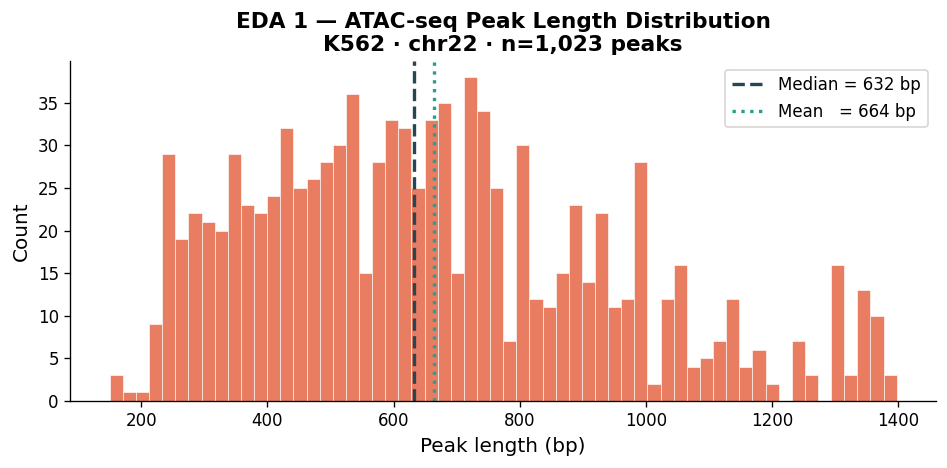

Min: 150 bp  |  Max: 1398 bp  |  Median: 632 bp


In [32]:
lengths = [e - s for s, e, _ in peaks]

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120})
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(lengths, bins=60, color="#E76F51", edgecolor="white",
        linewidth=0.4, alpha=0.9)
ax.axvline(np.median(lengths), color="#264653", lw=2, ls="--",
           label=f"Median = {int(np.median(lengths))} bp")
ax.axvline(np.mean(lengths), color="#2A9D8F", lw=2, ls=":",
           label=f"Mean   = {int(np.mean(lengths))} bp")

ax.set_xlabel("Peak length (bp)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("EDA 1 — ATAC-seq Peak Length Distribution\n"
             f"K562 · chr22 · n={len(lengths):,} peaks",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(PLOT_DIR / "eda1_peak_lengths.png")
plt.show()

print(f"Min: {min(lengths)} bp  |  Max: {max(lengths)} bp  "
      f"|  Median: {int(np.median(lengths))} bp")

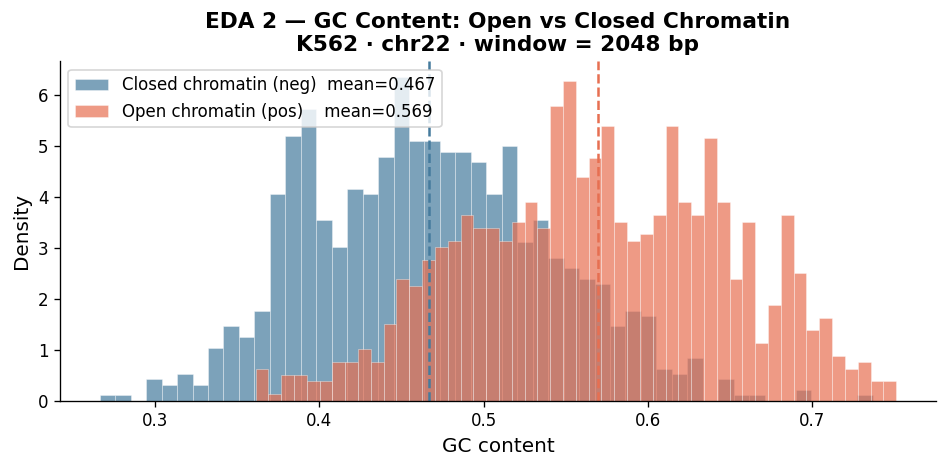

GC shift (open − closed): +0.1022  (enriched in open chromatin)


In [33]:
gc = (X[:, 1, :].sum(-1) + X[:, 2, :].sum(-1)) / SEQ_LEN

gc_pos = gc[y == 1]
gc_neg = gc[y == 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(gc_neg, bins=50, alpha=0.7, density=True, color="#457B9D",
        edgecolor="white", linewidth=0.3,
        label=f"Closed chromatin (neg)  mean={gc_neg.mean():.3f}")
ax.hist(gc_pos, bins=50, alpha=0.7, density=True, color="#E76F51",
        edgecolor="white", linewidth=0.3,
        label=f"Open chromatin (pos)    mean={gc_pos.mean():.3f}")

ax.axvline(gc_pos.mean(), color="#E76F51", lw=1.5, ls="--")
ax.axvline(gc_neg.mean(), color="#457B9D", lw=1.5, ls="--")

ax.set_xlabel("GC content", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("EDA 2 — GC Content: Open vs Closed Chromatin\n"
             f"K562 · chr22 · window = {SEQ_LEN} bp",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(PLOT_DIR / "eda2_gc_content.png")
plt.show()

delta = gc_pos.mean() - gc_neg.mean()
print(f"GC shift (open − closed): {delta:+.4f}  "
      f"({'enriched' if delta > 0 else 'depleted'} in open chromatin)")

In [34]:
#model architecture

class ResBlock(nn.Module):
  features: int
  kernel_size: int = 9
  @nn.compact
  def __call__(self, x):
    residual = x
    x=nn.LayerNorm()(x)
    x=nn.Conv(self.features, (self.kernel_size,), padding="SAME")(x)
    x=nn.gelu(x)
    x=nn.Conv(self.features, (self.kernel_size,), padding="SAME")(x)
    if residual.shape[-1] !=self.features:
      residual = nn.Dense(self.featues)(residual)
    return x+residual


class ChromatinPredictor(nn.Module):
  n_filters: int=N_FILTERS
  n_layers: int=N_LAYERS
  @nn.compact
  def __call__(self,x):
    x= jnp.transpose(x, (0, 2, 1))
    x= nn.Conv(self.n_filters, (15,), padding="SAME")(x)
    x = nn.gelu(x)
    for i in range(self.n_layers):
      x = ResBlock(self.n_filters)(x)
      if i<self.n_layers - 1:
        x = nn.avg_pool(x, (2,), strides = (2,), padding = "SAME")
    x = x.mean(axis=1)
    x = nn.gelu(nn.Dense(64)(x))
    return nn.Dense(1)(x).squeeze(-1)

In [35]:
model=ChromatinPredictor()
key=jax.random.PRNGKey(SEED)
dummy   = jnp.ones((1, 4, SEQ_LEN))
params  = model.init(key, dummy)["params"]

n_params = sum(p.size for p in jax.tree_util.tree_leaves(params))
print(f"Model initialised  |  Parameters: {n_params:,}")

Model initialised  |  Parameters: 1,493,249


In [36]:
tx    = optax.adam(LR)
state = train_state.TrainState.create(
    apply_fn=model.apply, params=params, tx=tx)

In [37]:
@jax.jit
def train_step(state, bx, by):
    def loss_fn(p):
        logits = state.apply_fn({"params": p}, bx)
        return optax.sigmoid_binary_cross_entropy(logits, by).mean()
    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    return state.apply_gradients(grads=grads), loss

@jax.jit
def pred_batch(state, bx):
    return jax.nn.sigmoid(state.apply_fn({"params": state.params}, bx))

def predict_all(state, X_arr, bs=256):
    return np.concatenate([
        np.array(pred_batch(state, jnp.array(X_arr[i:i+bs])))
        for i in range(0, len(X_arr), bs)
    ])

In [38]:
from tqdm.notebook import tqdm as tqdm_notebook

best_auroc, best_params = 0.0, state.params
history = {"train_loss": [], "val_auroc": []}

for epoch in tqdm_notebook(range(1, EPOCHS + 1), desc="Epochs"):
    idx = rng.permutation(len(X_tr))
    Xsh, ysh = X_tr[idx], y_tr[idx]
    epoch_losses = []

    for i in range(0, len(Xsh), BATCH_SIZE):
        bx = jnp.array(Xsh[i:i+BATCH_SIZE])
        by = jnp.array(ysh[i:i+BATCH_SIZE])
        state, loss = train_step(state, bx, by)
        epoch_losses.append(float(loss))

    val_preds = predict_all(state, X_val)
    auroc     = roc_auc_score(y_val, val_preds)

    history["train_loss"].append(np.mean(epoch_losses))
    history["val_auroc"].append(auroc)

    if auroc > best_auroc:
        best_auroc, best_params = auroc, state.params

    if epoch % 1 == 0:
        print(f"Epoch {epoch:3d}  loss={np.mean(epoch_losses):.4f}  "
              f"val_AUROC={auroc:.4f}{'  ✓ best' if auroc == best_auroc else ''}")

state = state.replace(params=best_params)
print(f"\nBest val AUROC: {best_auroc:.4f}")

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch   1  loss=0.6986  val_AUROC=0.8044  ✓ best
Epoch   2  loss=0.5203  val_AUROC=0.8190  ✓ best
Epoch   3  loss=0.5148  val_AUROC=0.8277  ✓ best
Epoch   4  loss=0.4782  val_AUROC=0.8340  ✓ best
Epoch   5  loss=0.4984  val_AUROC=0.8310
Epoch   6  loss=0.4745  val_AUROC=0.8377  ✓ best
Epoch   7  loss=0.5021  val_AUROC=0.8359
Epoch   8  loss=0.4766  val_AUROC=0.8381  ✓ best
Epoch   9  loss=0.4604  val_AUROC=0.8398  ✓ best
Epoch  10  loss=0.4498  val_AUROC=0.8409  ✓ best
Epoch  11  loss=0.4449  val_AUROC=0.8441  ✓ best
Epoch  12  loss=0.4416  val_AUROC=0.8453  ✓ best
Epoch  13  loss=0.4494  val_AUROC=0.8453  ✓ best
Epoch  14  loss=0.4456  val_AUROC=0.8438
Epoch  15  loss=0.4332  val_AUROC=0.8518  ✓ best
Epoch  16  loss=0.4329  val_AUROC=0.8456
Epoch  17  loss=0.4501  val_AUROC=0.8425
Epoch  18  loss=0.4591  val_AUROC=0.8410
Epoch  19  loss=0.4380  val_AUROC=0.8440
Epoch  20  loss=0.4294  val_AUROC=0.8450
Epoch  21  loss=0.4252  val_AUROC=0.8453
Epoch  22  loss=0.4155  val_AUROC=0.8453
Ep

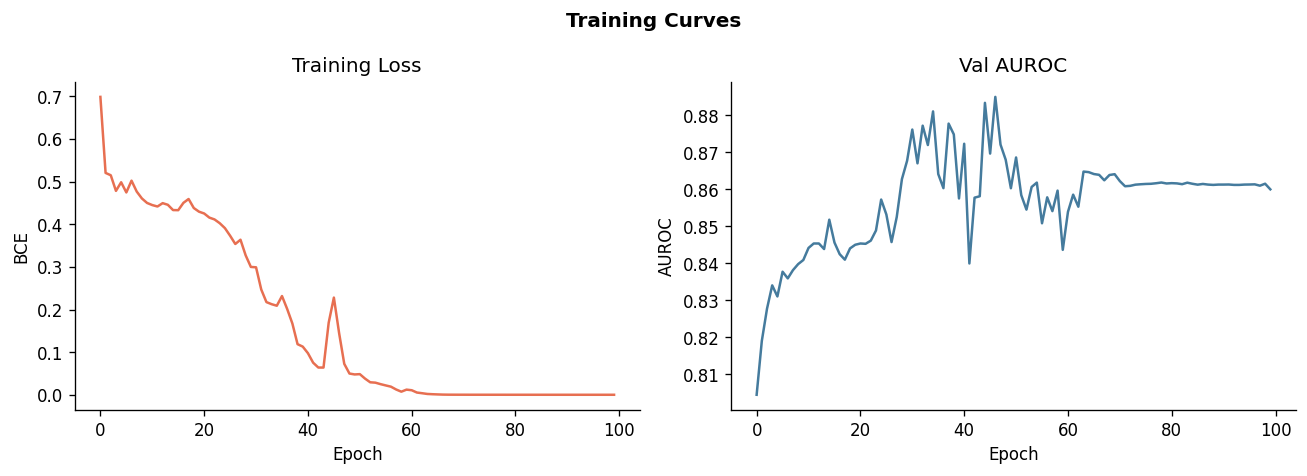

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history["train_loss"], color="#E76F51")
ax1.set_title("Training Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE")
ax2.plot(history["val_auroc"],  color="#457B9D")
ax2.set_title("Val AUROC");     ax2.set_xlabel("Epoch"); ax2.set_ylabel("AUROC")
for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.suptitle("Training Curves", fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "training_curves.png")
plt.show()

──────────────────────────────────────────
  AUROC               0.8463
  PR-AUC              0.8929
  Accuracy            0.7630
  Balanced Accuracy   0.7655
  F1 Score            0.7726
  MCC                 0.5288
  Log Loss            0.7070
  Sensitivity/Recall  0.7381
  Specificity         0.7929
  Precision (PPV)     0.8105
  NPV                 0.7161
  TP=124  FP=29  TN=111  FN=44
──────────────────────────────────────────


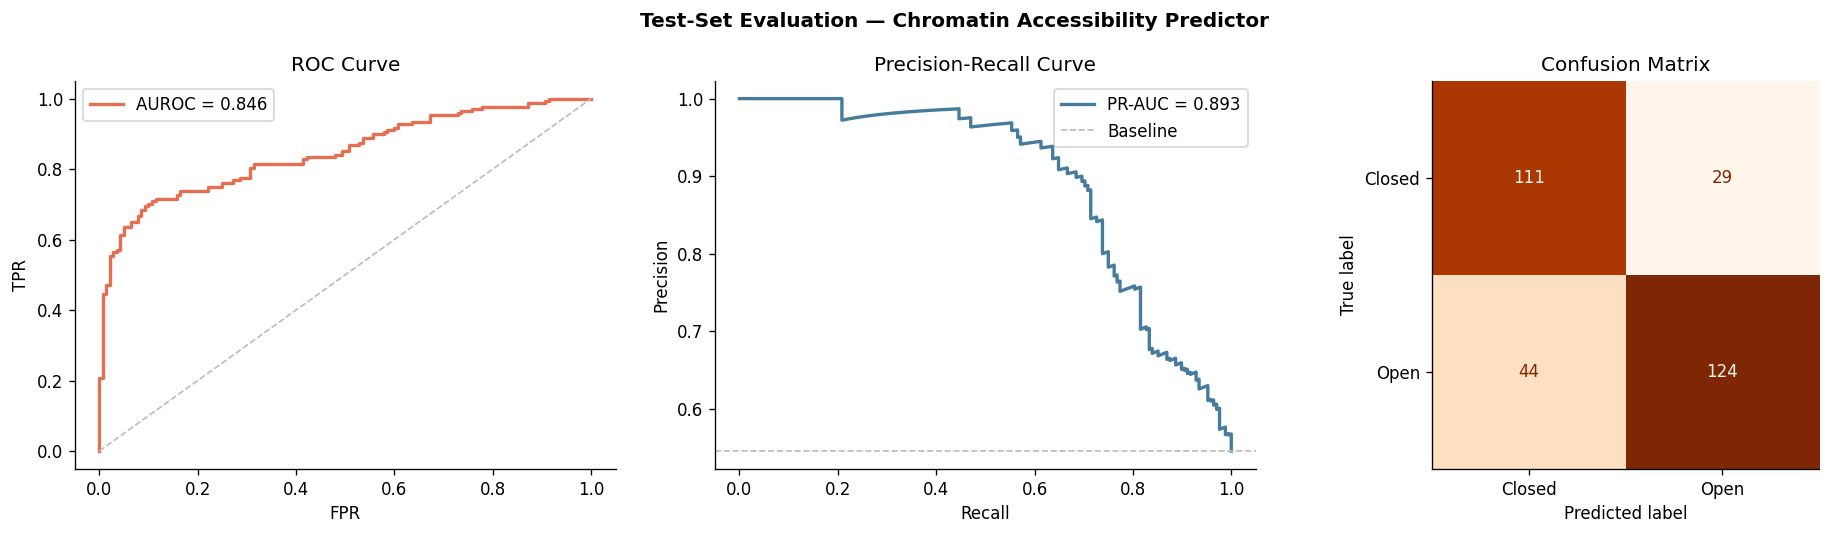

In [40]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    accuracy_score, f1_score, matthews_corrcoef,
    confusion_matrix, ConfusionMatrixDisplay,
    balanced_accuracy_score, log_loss,
)

test_preds  = predict_all(state, X_te)
test_labels = (test_preds >= 0.5).astype(int)

# ── Metrics ───────────────────────────────────────────────────────────────
auroc    = roc_auc_score(y_te, test_preds)
prauc    = average_precision_score(y_te, test_preds)
acc      = accuracy_score(y_te, test_labels)
bal_acc  = balanced_accuracy_score(y_te, test_labels)
f1       = f1_score(y_te, test_labels)
mcc      = matthews_corrcoef(y_te, test_labels)
logloss  = log_loss(y_te, test_preds)

tn, fp, fn, tp = confusion_matrix(y_te, test_labels).ravel()
sensitivity = tp / (tp + fn)          # recall / true positive rate
specificity = tn / (tn + fp)          # true negative rate
ppv         = tp / (tp + fp)          # precision / positive predictive value
npv         = tn / (tn + fn)          # negative predictive value

print("─" * 42)
print(f"  AUROC               {auroc:.4f}")
print(f"  PR-AUC              {prauc:.4f}")
print(f"  Accuracy            {acc:.4f}")
print(f"  Balanced Accuracy   {bal_acc:.4f}")
print(f"  F1 Score            {f1:.4f}")
print(f"  MCC                 {mcc:.4f}")
print(f"  Log Loss            {logloss:.4f}")
print(f"  Sensitivity/Recall  {sensitivity:.4f}")
print(f"  Specificity         {specificity:.4f}")
print(f"  Precision (PPV)     {ppv:.4f}")
print(f"  NPV                 {npv:.4f}")
print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
print("─" * 42)

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ROC
fpr, tpr, _ = roc_curve(y_te, test_preds)
axes[0].plot(fpr, tpr, color="#E76F51", lw=2, label=f"AUROC = {auroc:.3f}")
axes[0].plot([0,1],[0,1], "--", color="#bbb", lw=1)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve"); axes[0].legend(fontsize=10)

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_te, test_preds)
axes[1].plot(rec, prec, color="#457B9D", lw=2, label=f"PR-AUC = {prauc:.3f}")
axes[1].axhline(y_te.mean(), color="#bbb", lw=1, ls="--", label="Baseline")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend(fontsize=10)

# Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_te, test_labels),
    display_labels=["Closed", "Open"]
).plot(ax=axes[2], colorbar=False, cmap="Oranges")
axes[2].set_title("Confusion Matrix")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Test-Set Evaluation — Chromatin Accessibility Predictor",
             fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "eval_curves.png")
plt.show()

saliency: 100%|██████████| 50/50 [00:04<00:00, 10.76it/s]


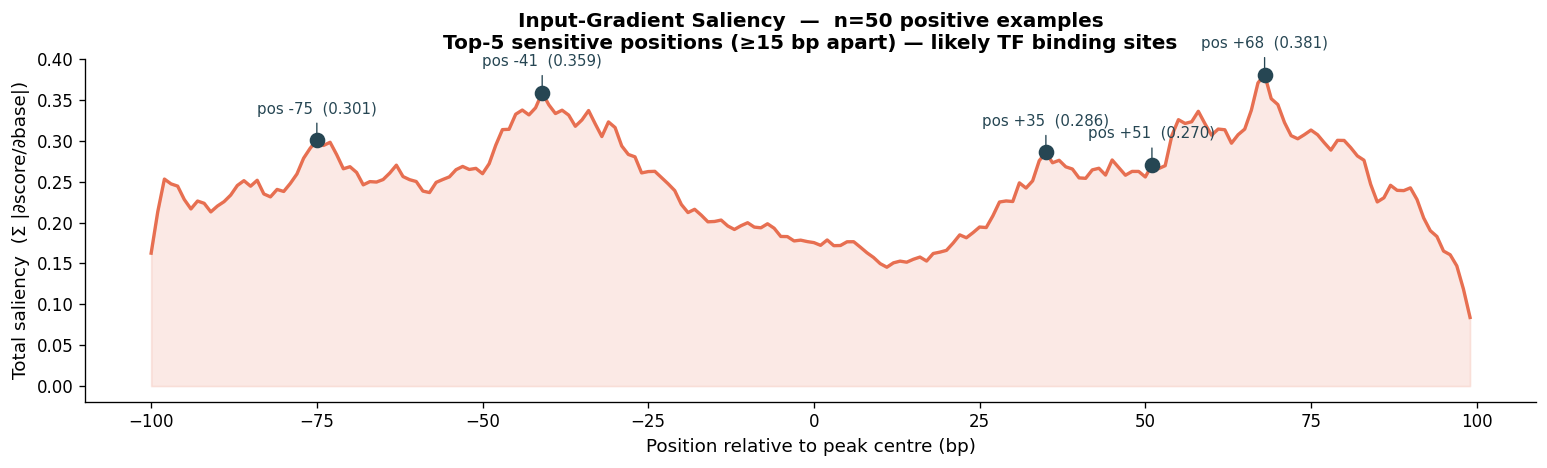

Top-5 salient positions (non-overlapping):
  pos  +68  saliency = 0.3811
  pos  -41  saliency = 0.3591
  pos  -75  saliency = 0.3009
  pos  +35  saliency = 0.2859
  pos  +51  saliency = 0.2705


In [45]:
def score_fn(x_single):
    return state.apply_fn({"params": state.params}, x_single[None])[0]

grad_fn = jax.jit(jax.grad(score_fn))

X_pos      = X_te[y_te == 1]
N_EXAMPLES = min(50, len(X_pos))
saliency   = np.zeros((4, SEQ_LEN), dtype=np.float32)

for x in tqdm(X_pos[:N_EXAMPLES], desc="saliency"):
    saliency += np.abs(np.array(grad_fn(jnp.array(x))))

saliency /= N_EXAMPLES

mid, win   = SEQ_LEN // 2, 100
positions  = np.arange(-win, win)
imp_window = saliency.sum(axis=0)[mid-win : mid+win]
imp_smooth = np.convolve(imp_window, np.ones(5)/5, mode="same")

# ── Non-maximum suppression: pick top peaks at least 15 bp apart ──────────
MIN_DIST  = 15
sorted_idx = imp_smooth.argsort()[::-1]
chosen, suppressed = [], set()
for i in sorted_idx:
    if i in suppressed:
        continue
    chosen.append(i)
    suppressed.update(range(i - MIN_DIST, i + MIN_DIST + 1))
    if len(chosen) == 5:
        break

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(positions, imp_smooth, alpha=0.15, color="#E76F51")
ax.plot(positions, imp_smooth, color="#E76F51", lw=2)

for i in chosen:
    ax.scatter(positions[i], imp_smooth[i], color="#264653", s=70, zorder=5)
    ax.annotate(
        f"pos {positions[i]:+d}  ({imp_smooth[i]:.3f})",
        xy=(positions[i], imp_smooth[i]),
        xytext=(0, 16),
        textcoords="offset points",
        ha="center", fontsize=9, color="#264653",
        arrowprops=dict(arrowstyle="-", color="#264653", lw=0.8),
    )

ax.set_xlabel("Position relative to peak centre (bp)", fontsize=11)
ax.set_ylabel("Total saliency  (Σ |∂score/∂base|)", fontsize=11)
ax.set_title(
    f"Input-Gradient Saliency  —  n={N_EXAMPLES} positive examples\n"
    "Top-5 sensitive positions (≥15 bp apart) — likely TF binding sites",
    fontsize=12, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(PLOT_DIR / "interpretation_saliency.png", dpi=150)
plt.show()

print("Top-5 salient positions (non-overlapping):")
for i in chosen:
    print(f"  pos {positions[i]:+4d}  saliency = {imp_smooth[i]:.4f}")